# Regresion Lineal del Costo del Seguro

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_original = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
print('El tamaño del dataset es de:', dataset_original.shape)
dataset_original.head()

El tamaño del dataset es de: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Charges es nuestro Y, ya que queremos predecir el costo de nuestro seguro dependiendo de los factores principalmente.
Los factores son:


*   Age:
*   Sex:
*   BMI: Body mass index, idealmente debería estar entre 18.5 y 24.9
*   Smoker: Si fuma o no la persona
*   Region: El area donde vive la persona beneficiaria

In [ ]:
#Encontrar valores nulos en la base de datos
dataset_original.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Pre processing

In [ ]:
dataset_original.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
#Imprimir los valores que tiene region
valores_unicos = dataset_original['region'].unique()
print(valores_unicos)

['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
dataset_original['sex'] = dataset_original['sex'].map({'male': 0, 'female': 1})
dataset_original['smoker'] = dataset_original['smoker'].map({'no': 0, 'yes': 1})
dataset_original['region'] = dataset_original['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})
dataset_original.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [ ]:
dataset_original.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


Imprimiremos un Heatmap de las correlaciones para encontrar valores que tengan mucha correlación entre ellos y encontrar predicciones con esos valores principalmente.

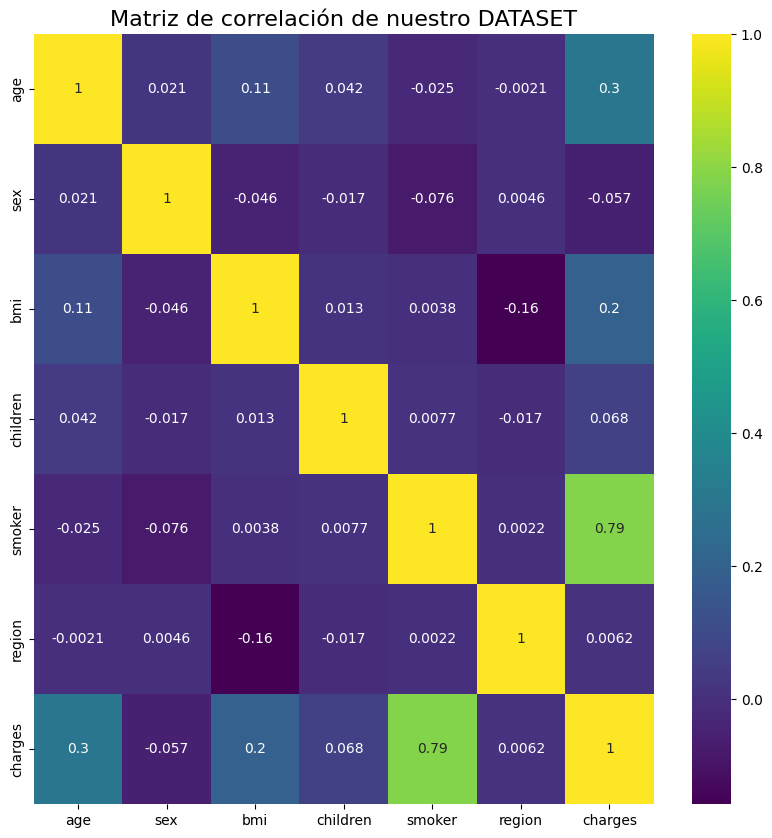

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax = sns.heatmap(dataset_original.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de nuestro DATASET', fontsize=16)

# Guardar el heatmap en un archivo
plt.savefig('/content/drive/MyDrive/Colab Notebooks/heatmap.png', bbox_inches='tight')

Encontramos una correlación muy alta con el 'smoker' y además se puede obtener algo con el age y bmi.

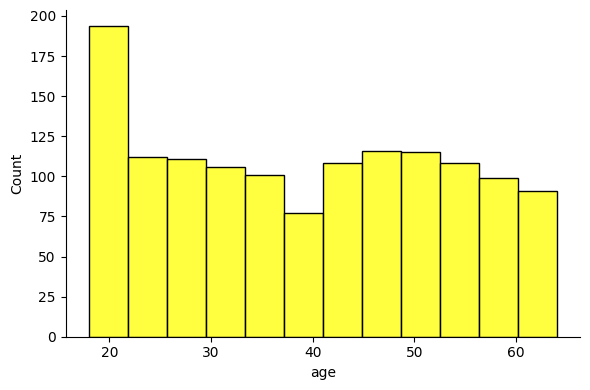

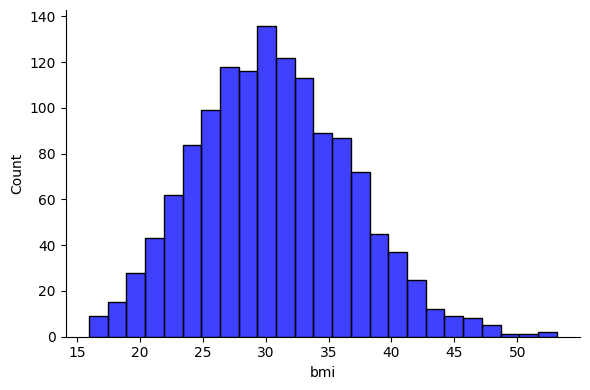

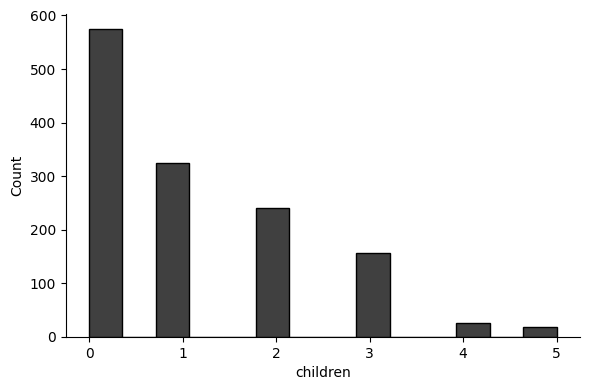

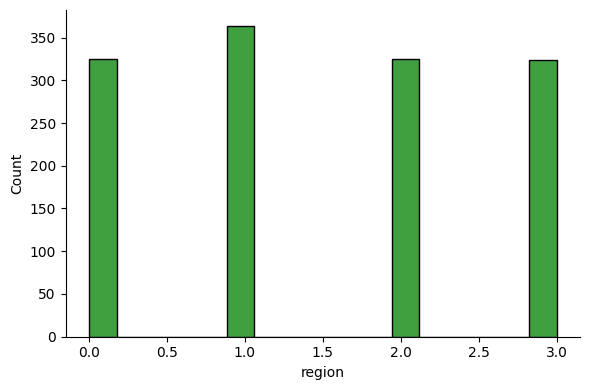

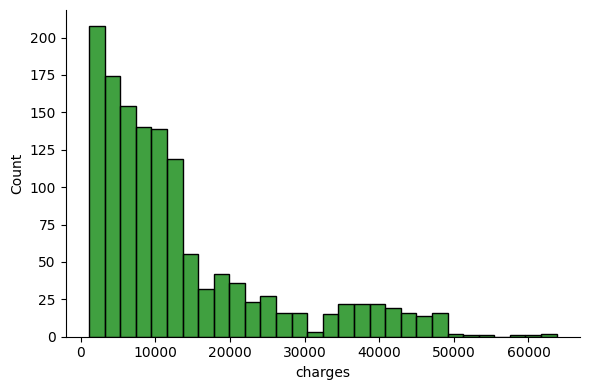

In [ ]:
import seaborn as sns

g1 = sns.displot(dataset_original, color = 'yellow', x="age", height=4, aspect=1.5)
#g2 = sns.displot(dataset_original, color = 'red', x="sex", height=4, aspect=1.5)
g3 = sns.displot(dataset_original, color = 'blue', x="bmi", height=4, aspect=1.5)
g4 = sns.displot(dataset_original, color = 'black', x="children", height=4, aspect=1.5)
#g5 = sns.displot(dataset_original, color = 'green', x="smoker", height=4, aspect=1.5)
g6 = sns.displot(dataset_original, color = 'green', x="region", height=4, aspect=1.5)
g7 = sns.displot(dataset_original, color = 'green', x="charges", height=4, aspect=1.5)



Encontramos costos impresionantes de $60,000$ y $50,000$ que pueden llegar a desbalancear la relación, además que son a muy pocas personas, por lo que se optó por cortarlo, así como valores de bmi impresionantes de 50, los cuáles se salen de la métrica tratada anteriormente.

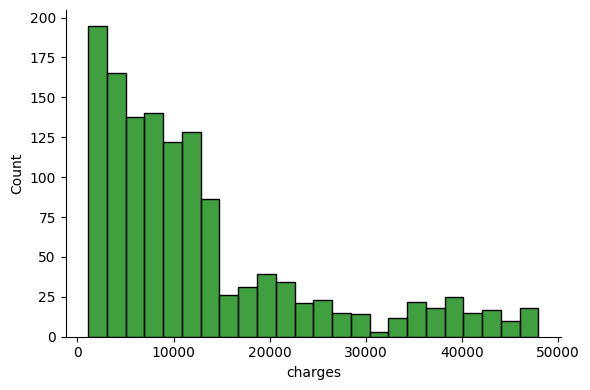

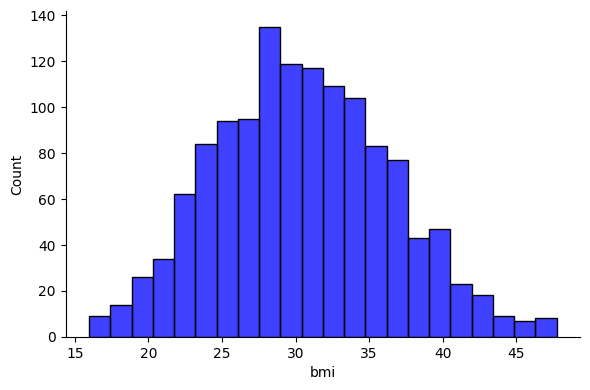

In [ ]:
dataset_edit = dataset_original.copy()
dataset_edit = dataset_edit[dataset_edit['charges'] <= 48000]
dataset_edit = dataset_edit[dataset_edit['bmi'] <= 48]

g1 = sns.displot(dataset_edit, color = 'green', x="charges", height=4, aspect=1.5)
g1 = sns.displot(dataset_edit, color = 'blue', x="bmi", height=4, aspect=1.5)


Volvemos a comparar la correlación

Text(0.5, 1.0, 'Matriz de correlación de datos editados')

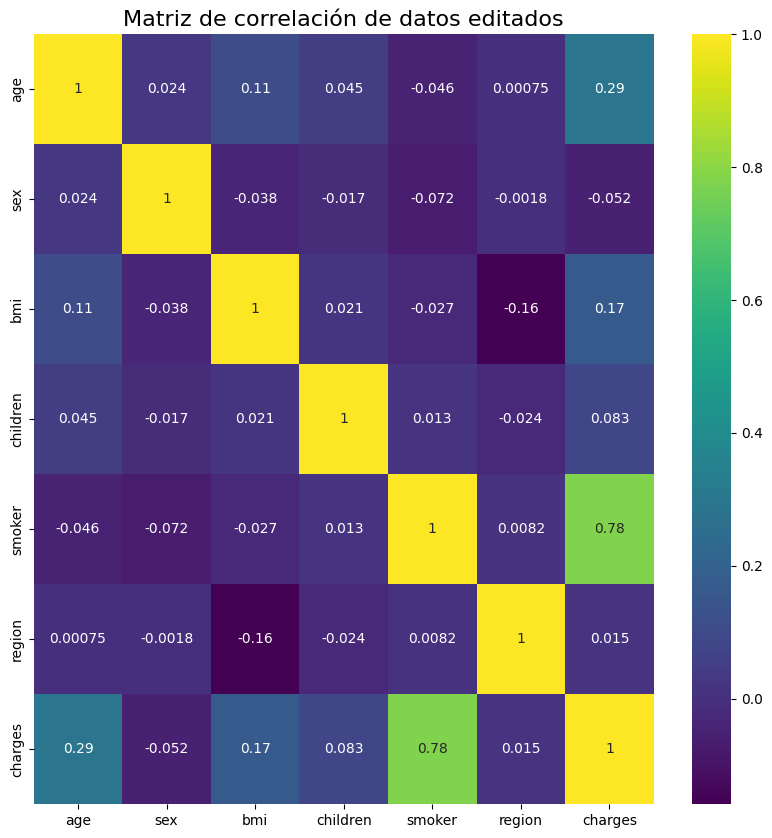

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax = sns.heatmap(dataset_edit.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de datos editados', fontsize=16)


AHORITA PODEMOS OBSERVAR QUE NUESTRAS CORRELACIONES BAJARON, PERO AL GRAFICAR SE VE UNA MEJOR RELACIÓN PORQUE SE ELIMINARON VALORES QUE ESTABAN MUY AFUERA DE NUESTROS VALORES BASE

### Análisis de nuestros datos EDA

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,3,1)
plt.title('Dispersión del valor de age vs el costo')
plt.ylabel('Costo ($)')
plt.xlabel('Edad')
plt.scatter(dataset_edit['age'], dataset_edit['charges'], color = 'black')

plt.subplot(1,3,2)
plt.title('Dispersión del valor de bmi vs el costo')
plt.ylabel('Costo ($)')
plt.xlabel('Indice de Masa Corporal (BMI)')
plt.scatter(dataset_edit['bmi'], dataset_edit['charges'], color = 'blue')


plt.subplot(1,3,3)
plt.title('Dispersión del valor de smoker vs el costo')
plt.ylabel('Costo ($)')
plt.xlabel('Fumador? Si/No')
plt.scatter(dataset_edit['smoker'], dataset_edit['charges'], color = 'green')

# Podemos observar que smoker no sirve para graficar y que no tienen una distribución real
# PERO EN PÁGINAS DONDE TAMBIÉN OCUPAN ÉSTA BASE DE DATOS LA DIVIDEN TOMANDO COMO FUMADORES

NameError: name 'plt' is not defined

#### Descomposición en Fumadores y NO Fumadores

In [ ]:
#dataset_original
dataset_smoker = dataset_edit.loc[dataset_edit['smoker'] == 1]
dataset_NO_smoker = dataset_edit.loc[dataset_edit['smoker'] == 0]
dataset_smoker.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

Text(0.5, 1.0, 'Correlación de los fumadores')

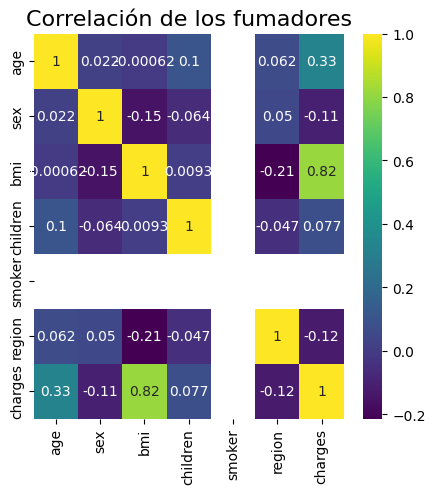

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = sns.heatmap(dataset_smoker.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los fumadores', fontsize=16)


Text(0.5, 1.0, 'Correlación de los no fumadores')

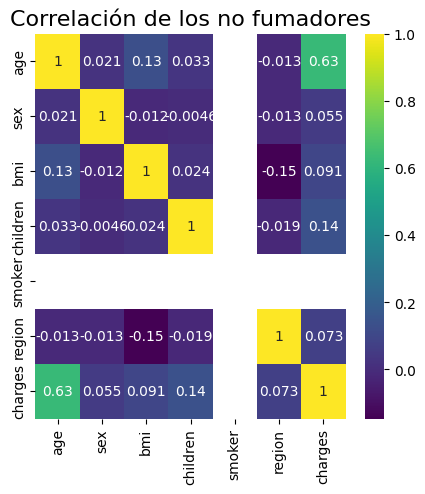

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = sns.heatmap(dataset_NO_smoker.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los no fumadores', fontsize=16)

Se está dividiendo en 2 porque dependiendo de si fuma o no, se encuentra una correlación diferente en las gráficas, y se podría predecir fácil en cada uno de los datasets por ejemplo, obtener la regresión de fumadores de age vs charges y aparte la regresión de no fumadores de age vs charges, y tal vez después sumarlas o dejar cada una sería bueno hacer pruebas.

Y así aplicarlo al de bmi vs charges.

También revisar si se puede encontrar una relación lineal con OTROS VALORES, como children vs charges o age vs bmi

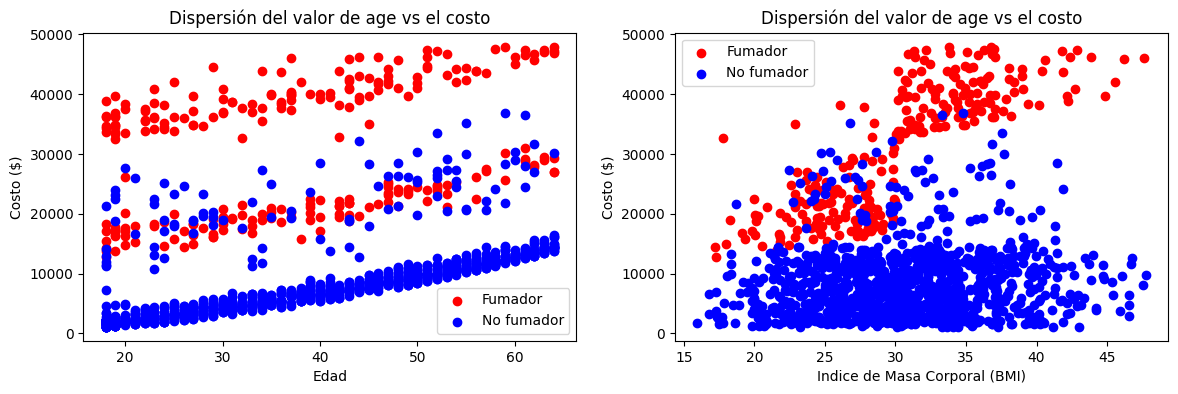

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Dispersión del valor de age vs el costo')
plt.ylabel('Costo ($)')
plt.xlabel('Edad')
plt.scatter(dataset_smoker['age'], dataset_smoker['charges'], color='red', label='Fumador')
plt.scatter(dataset_NO_smoker['age'], dataset_NO_smoker['charges'], color='blue', label='No fumador')
plt.legend()

plt.subplot(1,2,2)
plt.title('Dispersión del valor de age vs el costo')
plt.ylabel('Costo ($)')
plt.xlabel('Indice de Masa Corporal (BMI)')
plt.scatter(dataset_smoker['bmi'], dataset_smoker['charges'], color='red', label='Fumador')
plt.scatter(dataset_NO_smoker['bmi'], dataset_NO_smoker['charges'], color='blue', label='No fumador')
plt.legend()


#APLICAR REGRESIÓN LINEAL A ESTOS DATOS TAL CUÁL, Y COMPARAR CON LOS FILTRADOS

### Descomposición en Fumadores Obesos, Fumadores NO Obesos, NO Fumadores Obesos, NO Fumadores NO Obesos

Se encuentra que para los Fumadores NO Obesos hay una correlación muy fuerte con los hijos, por lo que se añadirá ésto a nuestro paper, pero solo como análisis sencillo

In [ ]:
#dataset_original
dataset_smoker_obese = dataset_smoker.loc[dataset_smoker['bmi'] >= 30]
dataset_smoker_no_obese = dataset_smoker.loc[dataset_smoker['bmi'] < 30]
dataset_smoker_obese.dtypes

dataset_NO_smoker_obese = dataset_NO_smoker.loc[dataset_NO_smoker['bmi'] >= 30]
dataset_NO_smoker_no_obese = dataset_NO_smoker.loc[dataset_NO_smoker['bmi'] < 30]



Text(0.5, 1.0, 'Correlación de los fumadores obesos')

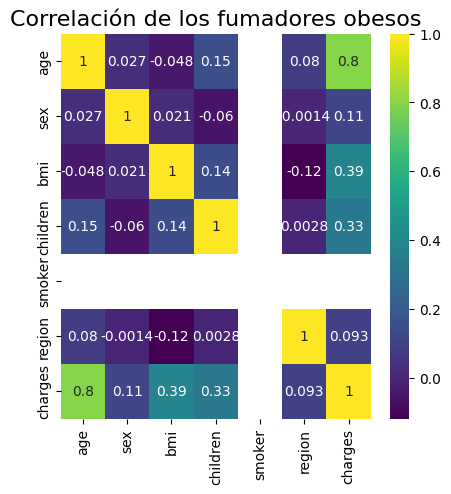

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_smoker_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los fumadores obesos', fontsize=16)

Text(0.5, 1.0, 'Correlación de los fumadores no obesos')

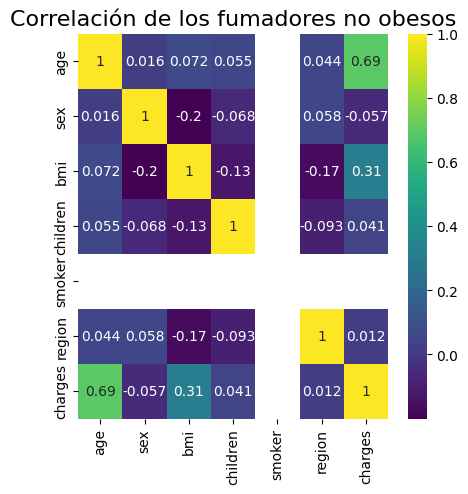

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_smoker_no_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los fumadores no obesos', fontsize=16)

Text(0.5, 1.0, 'Correlación de los no fumadores ni obesos')

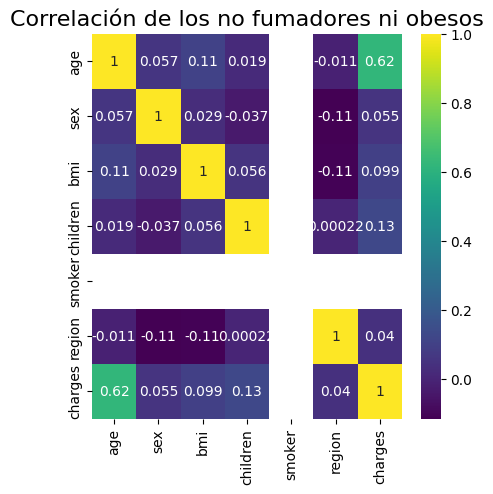

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_NO_smoker_no_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los no fumadores ni obesos', fontsize=16)

Text(0.5, 1.0, 'Correlación de los no fumadores obesos')

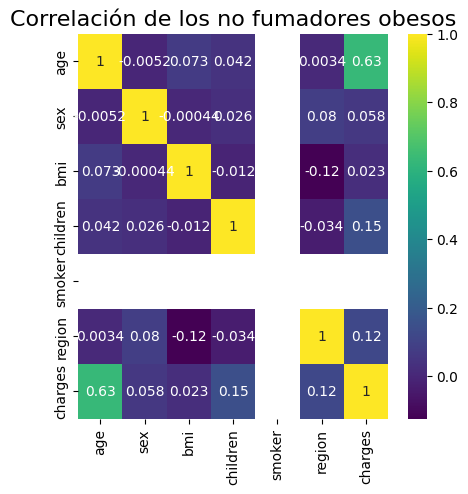

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_NO_smoker_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Correlación de los no fumadores obesos', fontsize=16)

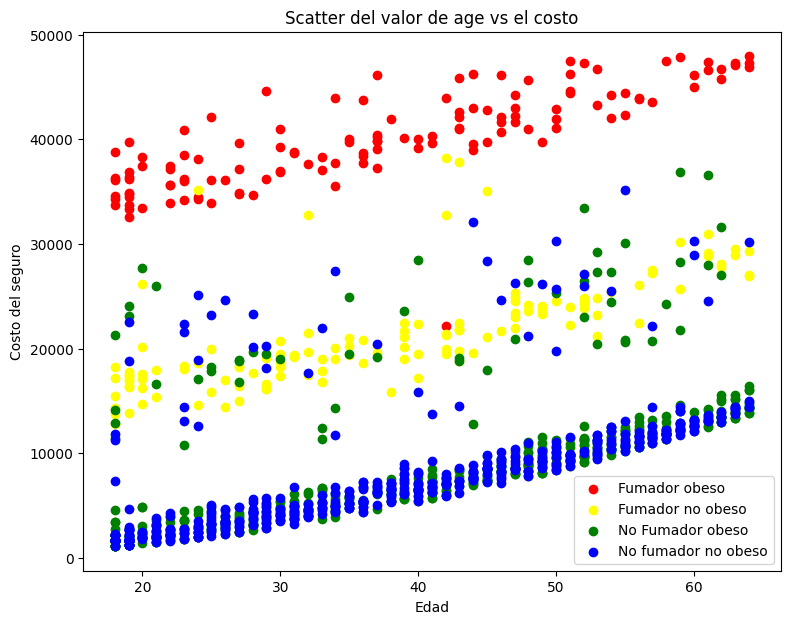

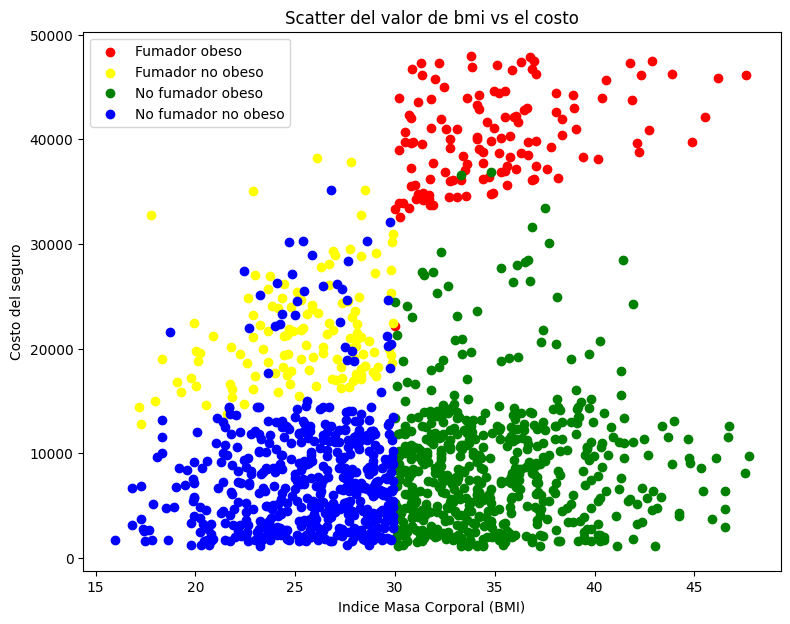

In [ ]:
#SE USARÁ ÉSTA GRÁFICA
plt.figure(figsize = (9,7))
#plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('Edad')
plt.ylabel('Costo del seguro')
plt.scatter(dataset_smoker_obese['age'], dataset_smoker_obese['charges'], color='red', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['age'], dataset_smoker_no_obese['charges'], color='yellow', label='Fumador no obeso')
plt.scatter(dataset_NO_smoker_obese['age'], dataset_NO_smoker_obese['charges'], color='green', label='No Fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['age'], dataset_NO_smoker_no_obese['charges'], color='blue', label='No fumador no obeso')

plt.legend()
plt.figure(figsize = (9,7))
#plt.subplot(1,2,2)
plt.title('Scatter del valor de bmi vs el costo')
plt.xlabel('Indice Masa Corporal (BMI)')
plt.ylabel('Costo del seguro')
plt.scatter(dataset_smoker_obese['bmi'], dataset_smoker_obese['charges'], color='red', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['bmi'], dataset_smoker_no_obese['charges'], color='yellow', label='Fumador no obeso')
plt.scatter(dataset_NO_smoker_obese['bmi'], dataset_NO_smoker_obese['charges'], color='green', label='No fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['bmi'], dataset_NO_smoker_no_obese['charges'], color='blue', label='No fumador no obeso')

plt.legend()

#### Eliminación de Outliers en nuestros 4 DATASETS **AGE**

In [ ]:
import numpy as np
def hip(theta_0,theta_1,x):
    h = theta_1*x + theta_0
    return h

def MSE(theta0,theta1,x,y):
    block = hip(theta0,theta1,x) - y

    m = len(x)
    return sum(block*block)/(2*m)

def MAE(theta0,theta1,x,y):
    block = hip(theta0,theta1,x) - y

    m = len(x)
    return (1/2*m)*sum(abs(block))



In [ ]:
def filtrado(x,y,theta0,theta1):
  n = len(x)
  filteredx = list()
  filteredy = list()
  #plt.scatter(x, y, marker='.', color='r', label="All Points")
  for i in range(1,n,1):
    h = hip(theta0,theta1,x[i])
    if y[i] < h:
        filteredx.append(x[i])
        filteredy.append(y[i])
  filteredx = np.array(filteredx)
  filteredy = np.array(filteredy)
  return filteredx,filteredy

Filtrado de No Smoker No Obese

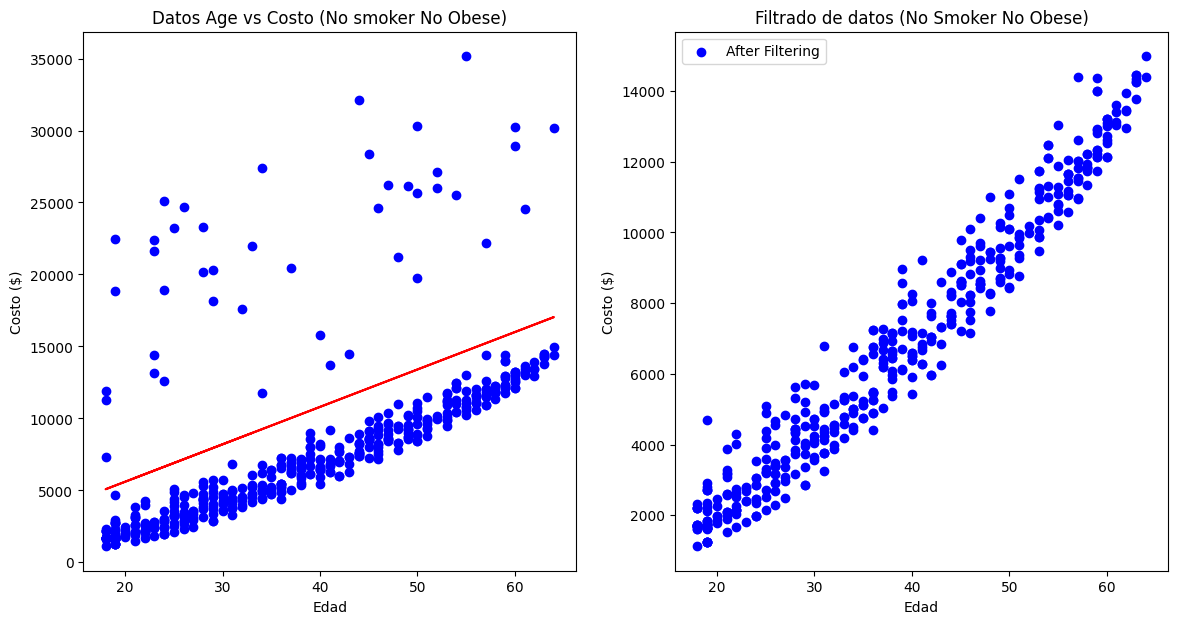

In [ ]:
import matplotlib.pyplot as plt
theta0=400
theta1=260

x_nos_nob = np.array(dataset_NO_smoker_no_obese['age'])
y_nos_nob = np.array(dataset_NO_smoker_no_obese['charges'])
h = hip(theta0,theta1,x_nos_nob)

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
plt.title('Datos Age vs Costo (No smoker No Obese)')
plt.ylabel('Costo ($)')
plt.xlabel('Edad')


plt.scatter(x_nos_nob,y_nos_nob, color='blue')
plt.plot(x_nos_nob,h,c='red')

plt.subplot(1,2,2)
plt.title('Filtrado de datos (No Smoker No Obese)')
plt.ylabel('Costo ($)')
plt.xlabel('Edad')
f_x_nos_nob, f_y_nos_nob = filtrado(x_nos_nob, y_nos_nob, theta0,theta1)
plt.scatter(f_x_nos_nob, f_y_nos_nob, marker='o', color='blue', label="After Filtering")
plt.legend()


Filtrado No Smoker Obese

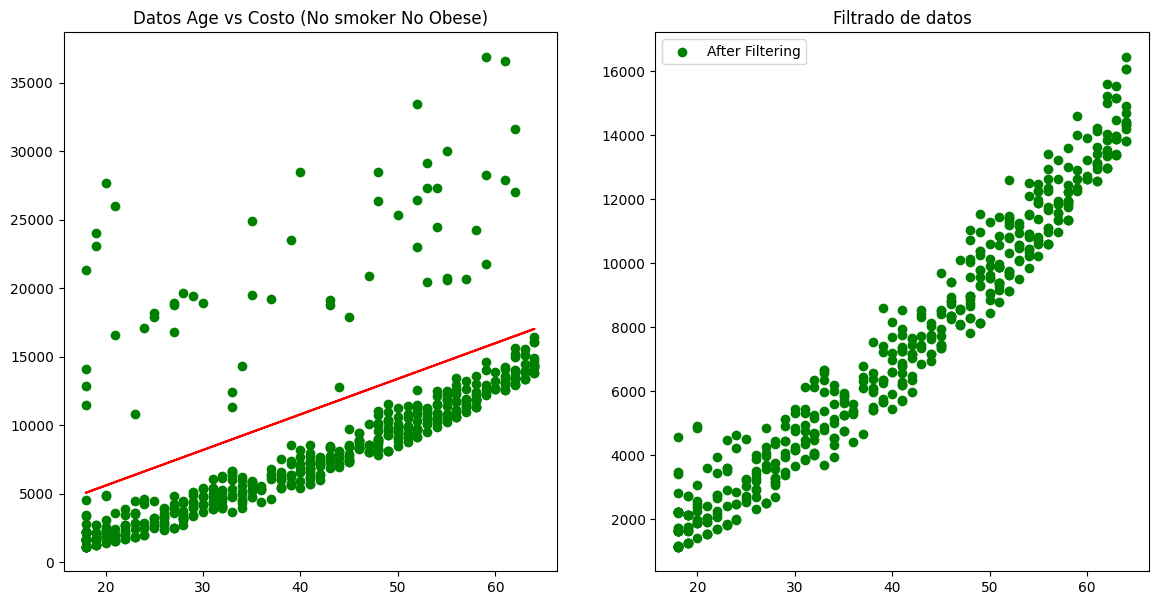

In [ ]:
import matplotlib.pyplot as plt
theta0=400
theta1=260

x_nos_ob = np.array(dataset_NO_smoker_obese['age']) #utilizo todo el dataset completo de no fumadores
y_nos_ob = np.array(dataset_NO_smoker_obese['charges'])
h = hip(theta0,theta1,x_nos_ob)

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
plt.title('Datos Age vs Costo (No smoker No Obese)')
plt.scatter(x_nos_ob,y_nos_ob, color='green')
plt.plot(x_nos_ob,h,c='red')


plt.subplot(1,2,2)
plt.title('Filtrado de datos')
f_x_nos_ob, f_y_nos_ob = filtrado(x_nos_ob, y_nos_ob, theta0,theta1)
plt.scatter(f_x_nos_ob, f_y_nos_ob, marker='o', color='green', label="After Filtering")
plt.legend()

Filtrado Smoker No Obese

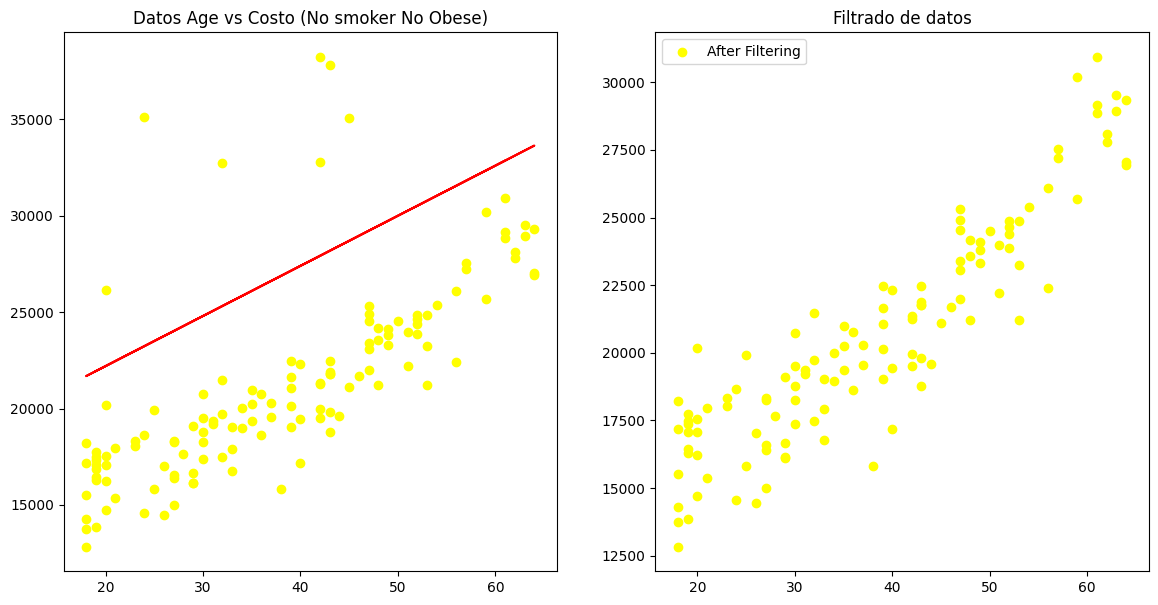

In [ ]:
import matplotlib.pyplot as plt
theta0=17000
theta1=260

x_s_nob = np.array(dataset_smoker_no_obese['age']) #utilizo todo el dataset completo de no fumadores
y_s_nob = np.array(dataset_smoker_no_obese['charges'])
h = hip(theta0,theta1,x_s_nob)

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
plt.title('Datos Age vs Costo (No smoker No Obese)')
plt.scatter(x_s_nob,y_s_nob, color='yellow')
plt.plot(x_s_nob,h,c='red')


plt.subplot(1,2,2)
plt.title('Filtrado de datos')
f_x_s_nob, f_y_s_nob = filtrado(x_s_nob, y_s_nob, theta0,theta1)
plt.scatter(f_x_s_nob, f_y_s_nob, marker='o', color='yellow', label="After Filtering")
plt.legend()

Los nuevos valores filtrados son los que empiezan con f

# ENTRENAMIENTO **AGE**

Los valores filtrados conrresponden de la siguiente manera:



*   No Smoker No Obese = f_x_nos_nob, f_y_nos_nob
*   No Smoker Obese = f_x_nos_ob, f_y_nos_ob
*   Smoker No Obese: f_x_s_nob, f_y_s_nob
*   Smoker Obese: dataset_NO_smoker_no_obese['age'], dataset_NO_smoker_no_obese['charges']


Para el Smoker Obese no se hizo filtrado porque la mayoría de los valores tenían una distribución uniforme





In [ ]:
import numpy as np
def hip(theta_0,theta_1,x):
    h = theta_1*x + theta_0
    return h

def MSE(h, Y):
  return np.sum((Y - h) ** 2) / (2 * (len(Y)))

def MAE(theta0,theta1,x,y):
    block = hip(theta0,theta1,x) - y

    m = len(x)
    return (1/2*m)*sum(abs(block))

def cal_costo(X, Y, theta_0, theta_1):
  h = hip(theta_0, theta_1,X)
  cost = MSE(h, Y)
  return h, cost


def gradiente_MSE(x, y, alpha, theta_0, theta_1, epocas):
    m = len(x)
    for _ in range(epocas):
        for j in range(m):
            theta_0 -= (alpha / m) * (hip(theta_0, theta_1,x[j]) - y[j])
            theta_1 -= (alpha / m) * (hip(theta_0, theta_1,x[j]) - y[j]) * x[j]

    return theta_0, theta_1

def plot(X, Y, theta_0, theta_1,col,lab):
  x = np.linspace(X.min(), X.max(), len(X))
  plt.plot(X, Y, marker='.', linestyle='none', label=lab, color = col)
  plt.plot(x, hip(theta_0, theta_1,x), label='Regresion Lineal del Modelo', color = 'black',linewidth = 2)
  plt.legend(loc="upper left")
  plt.xlabel('Edad')
  #plt.xlabel('Indice de Masa Corporal (BMI)')
  plt.ylabel('Costo ($)')
  plt.title('Regresión Lineal de ' + lab)
  plt.show()

def obtain_R2(h,Y):
  return (1 - sum((h-Y)**2)/sum((Y-np.mean(Y))**2))


$h_\theta(x)=\theta_1 x + \theta_0$

### Regresión No Fumadores No Obesos

Theta 0  =  -3450.869780827737
Theta 1  =  274.0859104646176
MSE  =  359899.0188095012
Valor de R2 =  0.9468730237527473


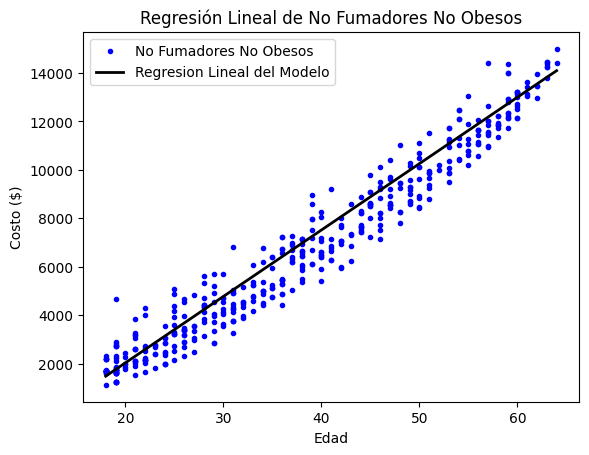

In [ ]:
theta_0=400
theta_1=260

X,Y = f_x_nos_nob, f_y_nos_nob

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.1, theta_0, theta_1, 5000)

print('Theta 0  = ', theta_0_new)
print('Theta 1  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'blue','No Fumadores No Obesos')

theta_0_blue = theta_0_new
theta_1_blue = theta_1_new

### Regresión No Fumadores Obesos

Theta 0  =  -3729.000486541368
Theta 0  =  286.95387679479154
MSE  =  549863.8165563566
Valor de R2 =  0.9308588666826224


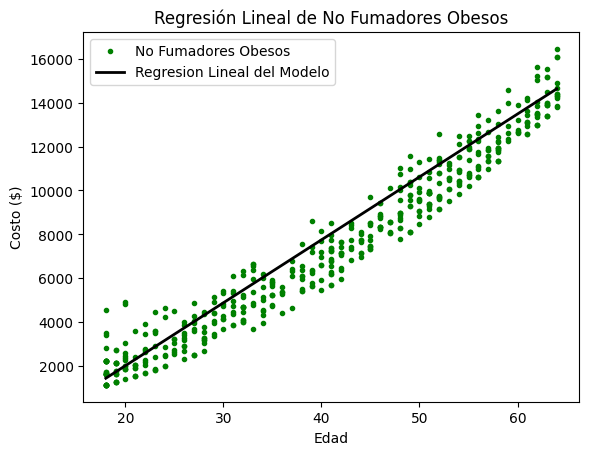

In [ ]:
theta_0=400
theta_1=260

X,Y = f_x_nos_ob, f_y_nos_ob

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.1, theta_0, theta_1, 5000)

print('Theta 0  = ', theta_0_new)
print('Theta 0  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'green','No Fumadores Obesos')

theta_0_green = theta_0_new
theta_1_green = theta_1_new

### Regresión Fumadores No Obesos

Theta 0  =  11955.476559371407
Theta 0  =  233.59237109640372
MSE  =  1581670.1827959346
Valor de R2 =  0.8077792300159484


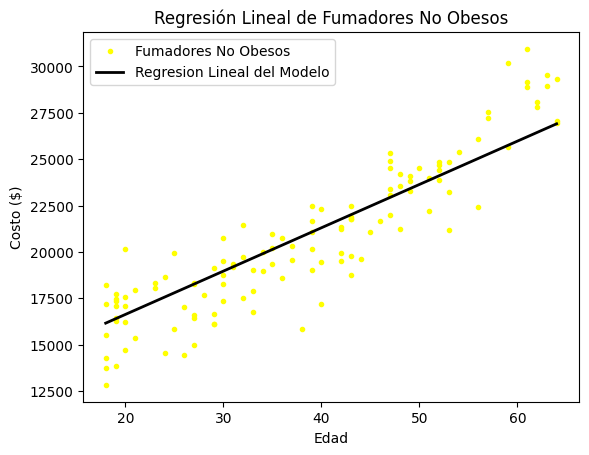

In [ ]:
theta_0=17000
theta_1=260

X,Y = f_x_s_nob, f_y_s_nob

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.1, theta_0, theta_1, 5000)

print('Theta 0  = ', theta_0_new)
print('Theta 0  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'yellow','Fumadores No Obesos')

theta_0_yellow = theta_0_new
theta_1_yellow = theta_1_new

### Regresion Fumadores Obesos

Theta 0  =  30444.931963296167
Theta 0  =  293.27167710615964
MSE  =  4671486.792474439
Valor de R2 =  0.5294347034435356


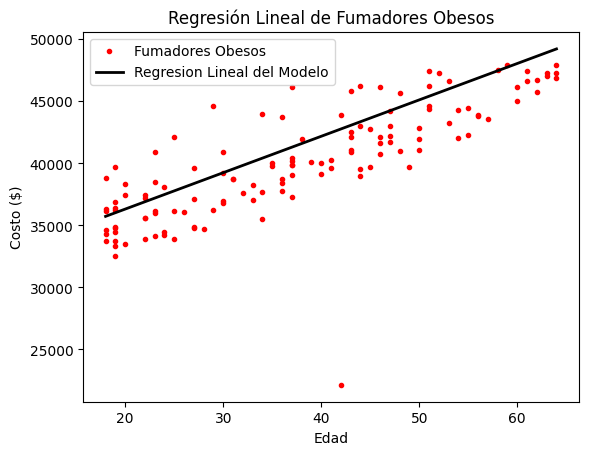

In [ ]:

theta_0=30000
theta_1=260

X = np.array(dataset_smoker_obese['age'])
Y = np.array(dataset_smoker_obese['charges'])

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.05, theta_0, theta_1, 10000)

print('Theta 0  = ', theta_0_new)
print('Theta 0  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'red','Fumadores Obesos')

theta_0_red = theta_0_new
theta_1_red = theta_1_new

# **IMPRESION DE TODAS LAS REGRESIONES ENCONTRADAS YA ENTRENADAS AGE**

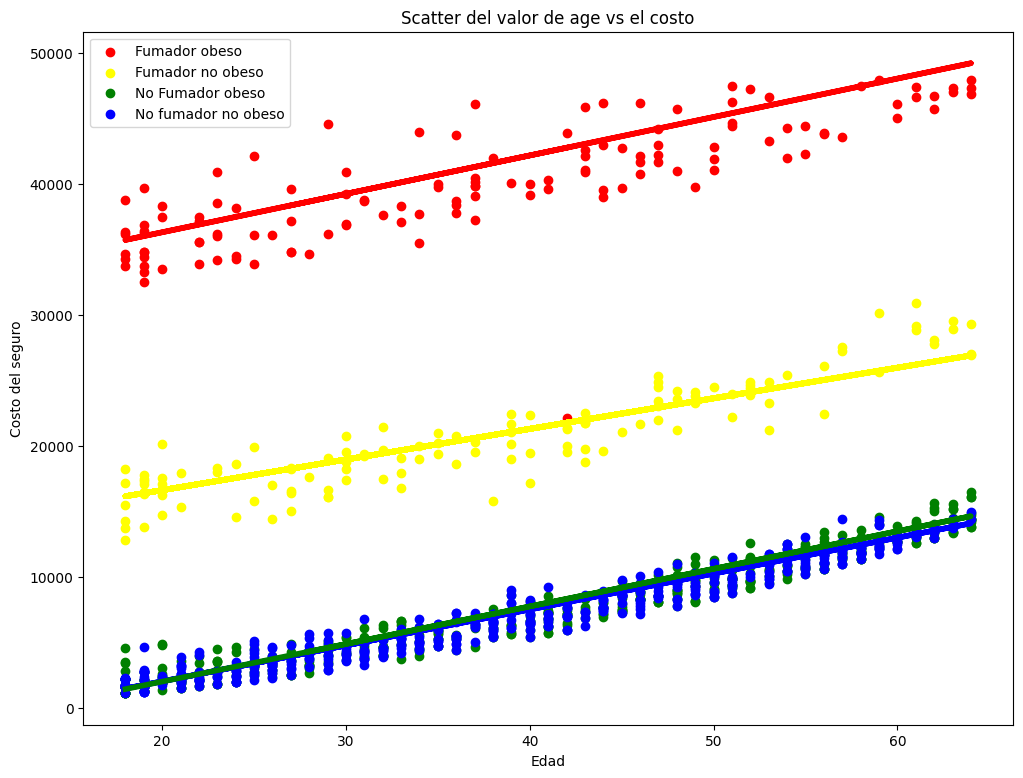

In [ ]:
plt.figure(figsize = (12,9))
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('Edad')
plt.ylabel('Costo del seguro')
plt.scatter(dataset_smoker_obese['age'],dataset_smoker_obese['charges'], color='red', label='Fumador obeso')
plt.scatter(f_x_s_nob, f_y_s_nob, color='yellow', label='Fumador no obeso')
plt.scatter(f_x_nos_ob, f_y_nos_ob, color='green', label='No Fumador obeso')
plt.scatter(f_x_nos_nob, f_y_nos_nob, color='blue', label='No fumador no obeso')

plt.plot(f_x_nos_nob, hip(theta_0_blue, theta_1_blue,f_x_nos_nob), color = 'blue',linewidth = 4)
plt.plot(f_x_nos_ob, hip(theta_0_green, theta_1_green,f_x_nos_ob), color = 'green',linewidth = 4)
plt.plot(f_x_s_nob, hip(theta_0_yellow, theta_1_yellow,f_x_s_nob), color = 'yellow',linewidth = 4)
plt.plot(dataset_smoker_obese['age'], hip(theta_0_red, theta_1_red,dataset_smoker_obese['age']), color = 'red',linewidth = 4)
plt.legend()

# **IMPRESIÓN DE TODAS LAS IMPRESIONES YA ENCONTRADAS BMI**

Theta 0  =  -11897.02516320064
Theta 0  =  1396.8578998571938
MSE  =  18747622.098664567
Valor de R2 =  0.661813652266037


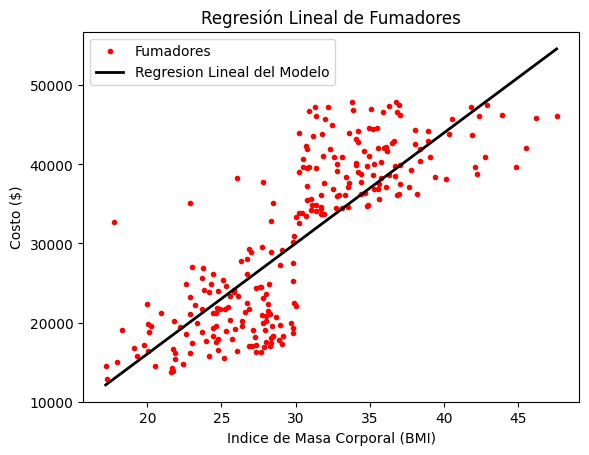

In [ ]:
theta_0=400
theta_1=260

X = np.array(dataset_smoker['bmi'])
Y = np.array(dataset_smoker['charges'])

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.2, theta_0, theta_1, 5000)

print('Theta 0  = ', theta_0_new)
print('Theta 0  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'red','Fumadores')
theta_0_red_bmi = theta_0_new
theta_1_red_bmi = theta_1_new

Theta 0  =  5855.428555021551
Theta 0  =  19.066578351041933
MSE  =  19920681.544343304
Valor de R2 =  -0.10873435170386303


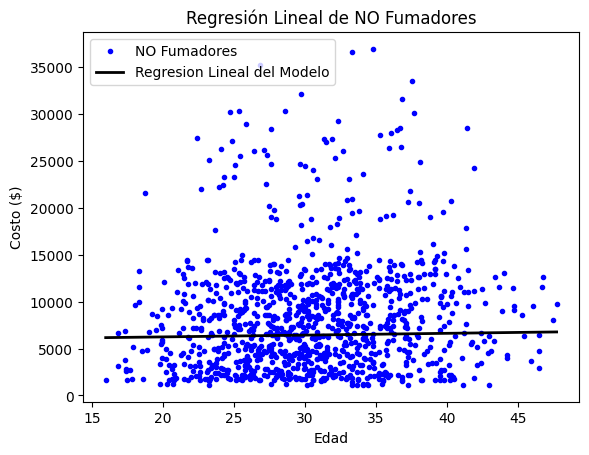

In [ ]:
theta_0=400
theta_1=260

X = np.array(dataset_NO_smoker['bmi'])
Y = np.array(dataset_NO_smoker['charges'])

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.2, theta_0, theta_1, 10000)

print('Theta 0  = ', theta_0_new)
print('Theta 0  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'blue','NO Fumadores')

theta_0_blue_bmi = theta_0_new
theta_1_blue_bmi = theta_1_new

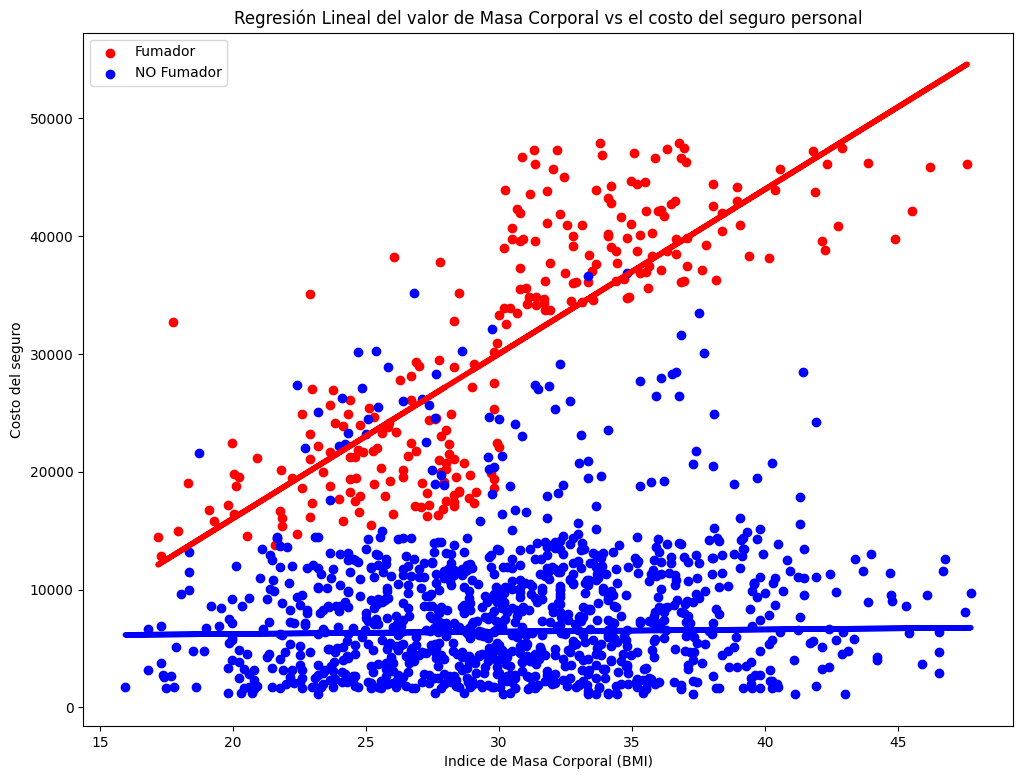

In [ ]:
plt.figure(figsize = (12,9))
plt.title('Regresión Lineal del valor de Masa Corporal vs el costo del seguro personal')
plt.xlabel('Indice de Masa Corporal (BMI)')
plt.ylabel('Costo del seguro')
plt.scatter(dataset_smoker['bmi'],dataset_smoker['charges'], color='red', label='Fumador')
plt.scatter(dataset_NO_smoker['bmi'],dataset_NO_smoker['charges'], color='blue', label='NO Fumador')

plt.plot(dataset_smoker['bmi'], hip(theta_0_red_bmi, theta_1_red_bmi,dataset_smoker['bmi']), color = 'red',linewidth = 4)
plt.plot(dataset_NO_smoker['bmi'], hip(theta_0_blue_bmi, theta_1_blue_bmi,dataset_NO_smoker['bmi']), color = 'blue',linewidth = 4)

plt.legend()

# Analisis NO Fumadores con Hijos

In [ ]:
#dataset_original
dataset_NO_smoker_0_children = dataset_NO_smoker.loc[dataset_edit['children'] == 0]
dataset_NO_smoker_1_children = dataset_NO_smoker.loc[dataset_edit['children'] == 1]
dataset_NO_smoker_2_children = dataset_NO_smoker.loc[dataset_edit['children'] == 2]
dataset_NO_smoker_3_children = dataset_NO_smoker.loc[dataset_edit['children'] == 3]
dataset_NO_smoker_4_children = dataset_NO_smoker.loc[dataset_edit['children'] == 4]
dataset_NO_smoker_5_children = dataset_NO_smoker.loc[dataset_edit['children'] == 5]


dataset_smoker_0_children = dataset_smoker.loc[dataset_edit['children'] == 0]
dataset_smoker_1_children = dataset_smoker.loc[dataset_edit['children'] == 1]
dataset_smoker_2_children = dataset_smoker.loc[dataset_edit['children'] == 2]
dataset_smoker_3_children = dataset_smoker.loc[dataset_edit['children'] == 3]
dataset_smoker_4_children = dataset_smoker.loc[dataset_edit['children'] == 4]
dataset_smoker_5_children = dataset_smoker.loc[dataset_edit['children'] == 5]

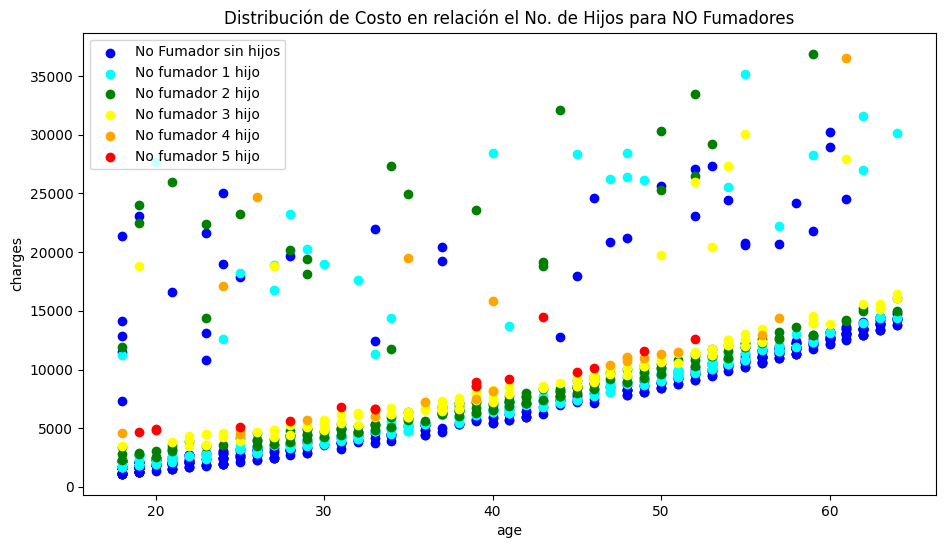

In [ ]:
#ÉSTA GRÁFICA SE QUEDA
plt.figure(figsize = (11,6))
plt.title('Distribución de Costo en relación el No. de Hijos para NO Fumadores')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_0_children['age'], dataset_NO_smoker_0_children['charges'], color='blue', label='No Fumador sin hijos')
plt.scatter(dataset_NO_smoker_1_children['age'], dataset_NO_smoker_1_children['charges'], color='cyan', label='No fumador 1 hijo')
plt.scatter(dataset_NO_smoker_2_children['age'], dataset_NO_smoker_2_children['charges'], color='green', label='No fumador 2 hijo')
plt.scatter(dataset_NO_smoker_3_children['age'], dataset_NO_smoker_3_children['charges'], color='yellow', label='No fumador 3 hijo')
plt.scatter(dataset_NO_smoker_4_children['age'], dataset_NO_smoker_4_children['charges'], color='orange', label='No fumador 4 hijo')
plt.scatter(dataset_NO_smoker_5_children['age'], dataset_NO_smoker_5_children['charges'], color='red', label='No fumador 5 hijo')
plt.legend()


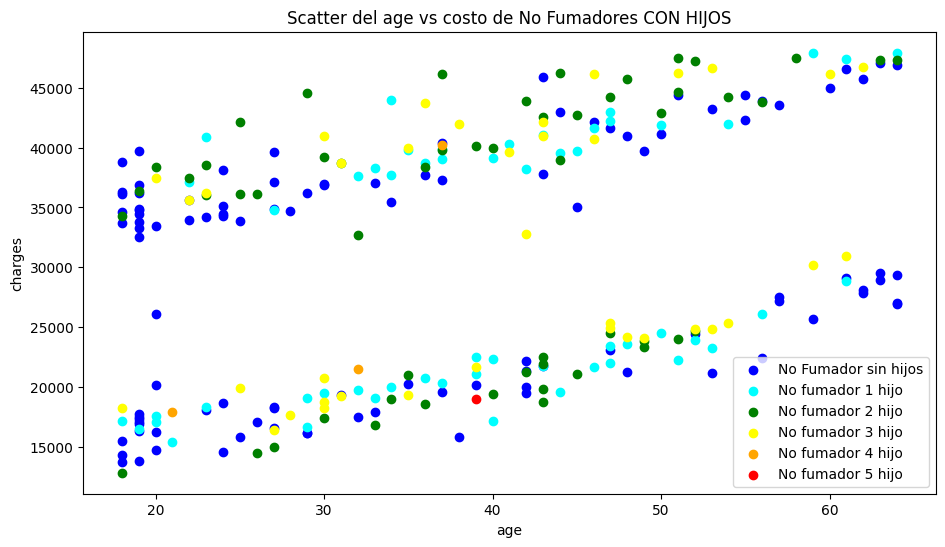

In [ ]:
#ÉSTA GRÁFICA SE QUEDA PERO SOLO PARA EXPLICAR QUE SI SON FUMADORES YA NO IMPORTA EL NÚMERO DE HIJOS PORQUE LA GRÁFICA ESTÁ MUY DISPERSA
plt.figure(figsize = (11,6))
plt.title('Scatter del age vs costo de Fumadores CON HIJOS')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_smoker_0_children['age'], dataset_smoker_0_children['charges'], color='blue', label='No Fumador sin hijos')
plt.scatter(dataset_smoker_1_children['age'], dataset_smoker_1_children['charges'], color='cyan', label='No fumador 1 hijo')
plt.scatter(dataset_smoker_2_children['age'], dataset_smoker_2_children['charges'], color='green', label='No fumador 2 hijo')
plt.scatter(dataset_smoker_3_children['age'], dataset_smoker_3_children['charges'], color='yellow', label='No fumador 3 hijo')
plt.scatter(dataset_smoker_4_children['age'], dataset_smoker_4_children['charges'], color='orange', label='No fumador 4 hijo')
plt.scatter(dataset_smoker_5_children['age'], dataset_smoker_5_children['charges'], color='red', label='No fumador 5 hijo')
plt.legend()

# ENTRENAMIENTO DE AGE SIN FILTRAR NI CATEGORIZAR

Theta 0  =  3768.02964112238
Theta 1  =  285.3146715926712
MSE  =  61327815.361924976
Valor de R2 =  0.04538500992776573


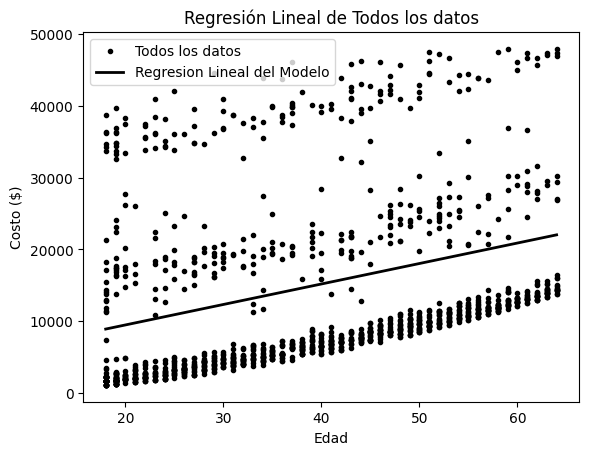

In [ ]:
theta_0=400
theta_1=260

X = np.array(dataset_edit['age'])
Y = np.array(dataset_edit['charges'])

theta_0_new, theta_1_new = gradiente_MSE(X, Y, 0.2, theta_0, theta_1, 5000)

print('Theta 0  = ', theta_0_new)
print('Theta 1  = ', theta_1_new)


h, cost = cal_costo(X, Y, theta_0_new, theta_1_new)
print('MSE  = ', cost)

print('Valor de R2 = ',obtain_R2(h,Y))
plot(X, Y, theta_0_new, theta_1_new, 'black','Todos los datos')

theta_0_general = theta_0_new
theta_1_general = theta_1_new